<a href="https://colab.research.google.com/github/lukasakar19-byte/Analisis-Regresi/blob/main/UAS_ANREG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**UAS**

# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca Data

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
data = pd.read_csv("/content/gdrive/My Drive/Analisis Regresi/UAS/karhutla_308.csv")
data.info()
data.head()

Mounted at /content/gdrive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   waktu              200 non-null    int64  
 1   jumlah_hotspot     200 non-null    float64
 2   curah_hujan        200 non-null    float64
 3   suhu               200 non-null    float64
 4   kelembaban         200 non-null    float64
 5   kecepatan_angin    200 non-null    float64
 6   luas_gambut        200 non-null    float64
 7   aktivitas_manusia  200 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 12.6 KB


,waktu,jumlah_hotspot,curah_hujan,suhu,kelembaban,kecepatan_angin,luas_gambut,aktivitas_manusia
0,0,225.785850,294.647007,31.845645,68.966509,4.679783,5750.368465,-0.255473
1,1,224.105221,220.978633,32.463660,66.728810,3.805794,3792.437093,0.185422
2,2,158.780413,81.183365,33.903492,63.744425,3.364234,5135.557250,-1.169242
3,3,310.220588,203.219077,34.952196,66.967840,7.502700,8401.212645,-0.183759
4,4,265.604392,199.914905,33.977463,66.275833,7.819249,7391.018934,-1.626211


In [ ]:
print("Total Missing Value:", data.isna().sum().sum())
print("Total Duplikat:", data.duplicated().sum())

Total Missing Value: 0
Total Duplikat: 0


## Deteksi Outlier

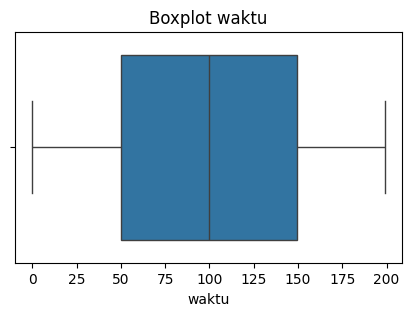

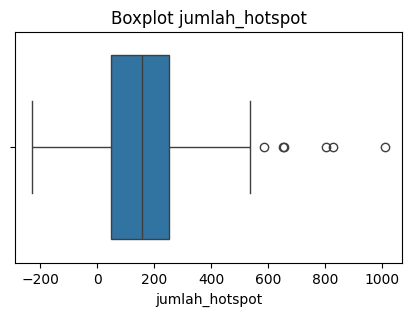

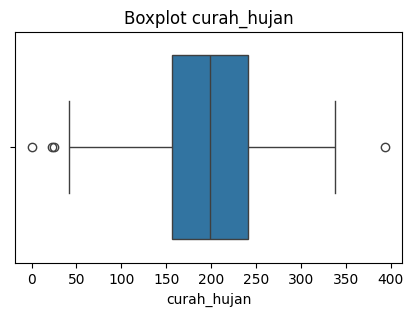

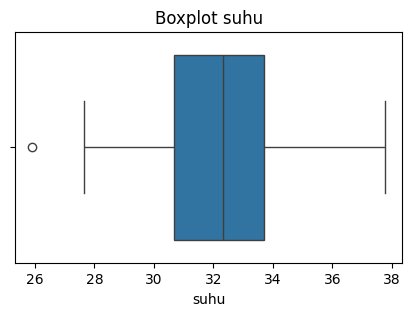

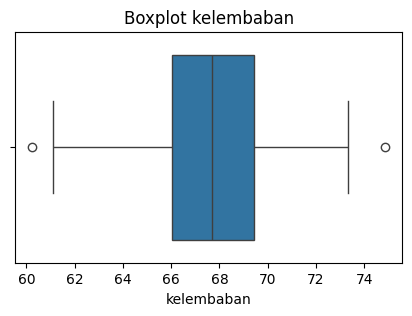

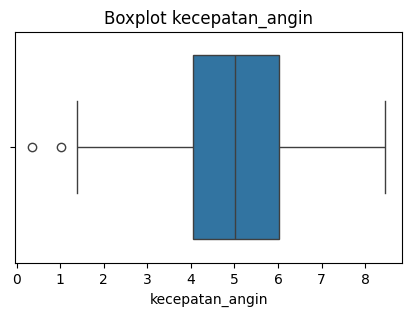

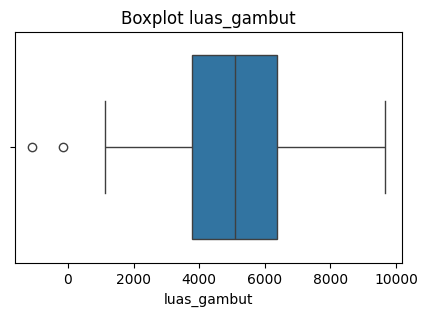

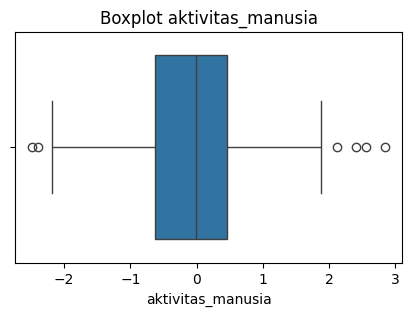

In [ ]:
for col in data.columns:
  plt.figure(figsize=(5,3))
  sns.boxplot(x=data[col])
  plt.title(f'Boxplot {col}')
  plt.show()

Berdasarkan boxplot, variabel waktu tidak terdeteksi outlier. Selain itu, terdeteksi outlier untuk variabel lain yaitu berupa titik kecil diluar whisker boxplot

## Scatter Plot

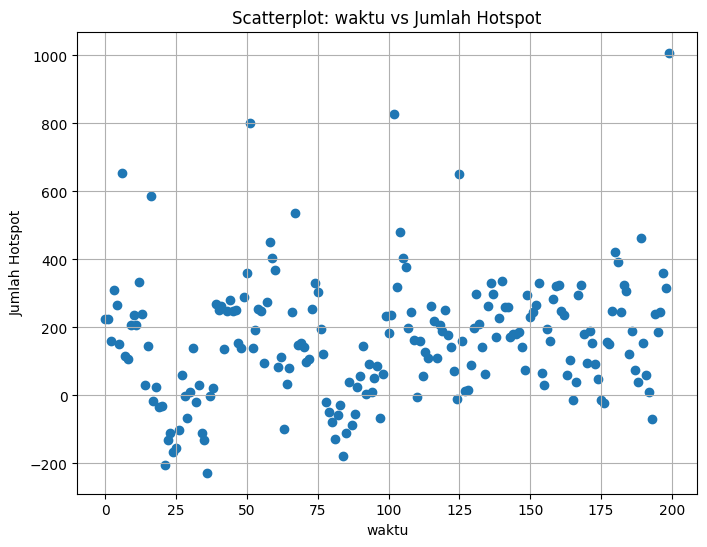

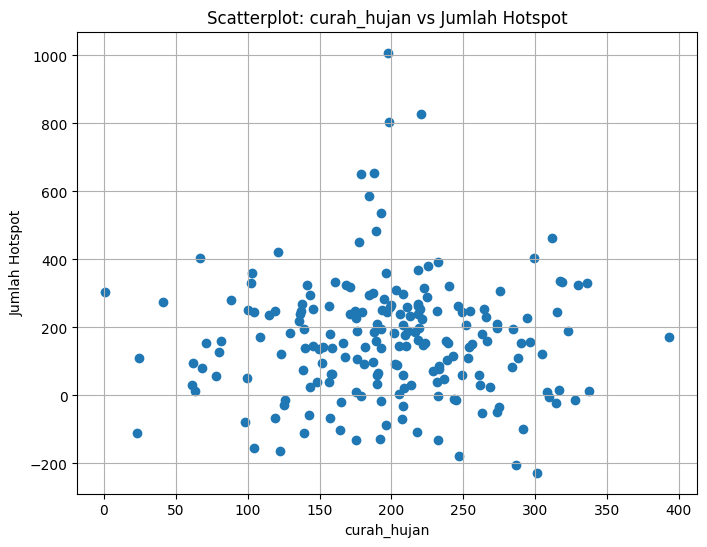

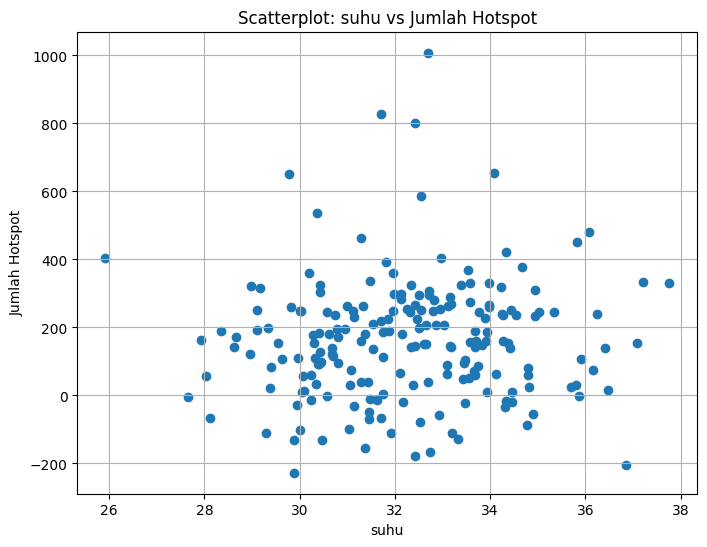

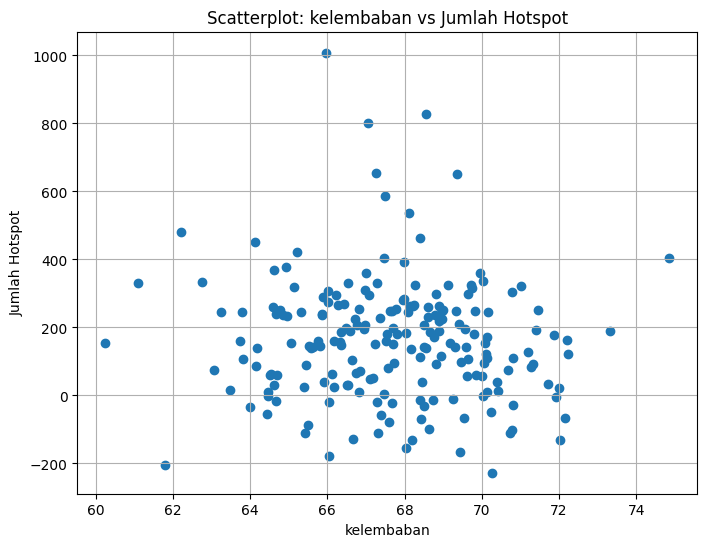

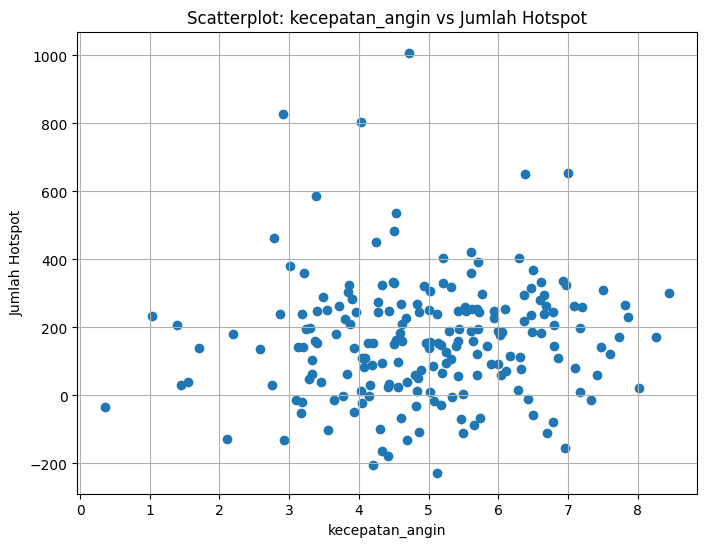

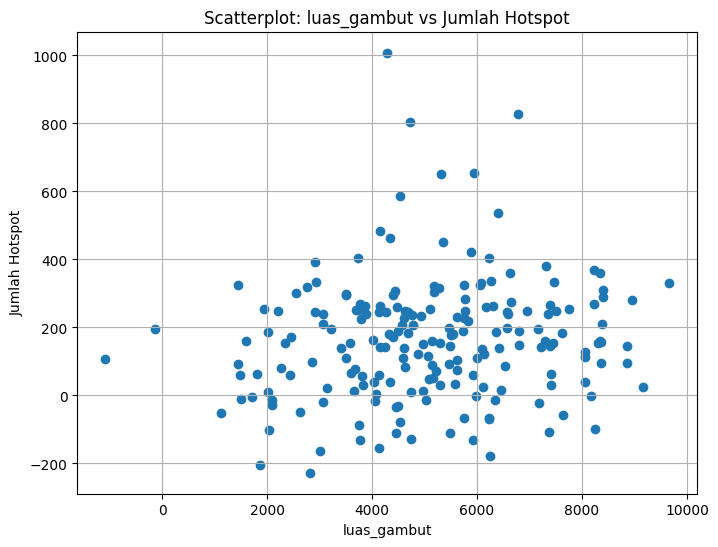

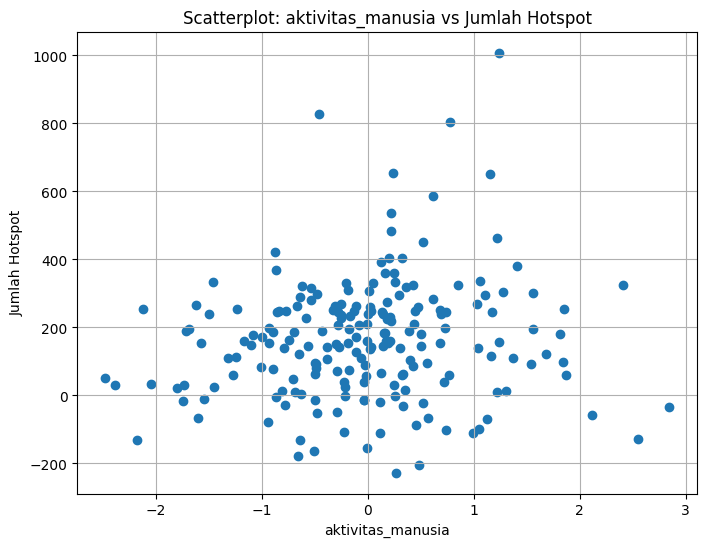

In [ ]:
y_plot_values = data['jumlah_hotspot']

for col_name in data.columns:
    if col_name == 'jumlah_hotspot':
        continue
    plt.figure(figsize=(8, 6))
    plt.scatter(data[col_name], y_plot_values)
    plt.xlabel(col_name)
    plt.ylabel('Jumlah Hotspot')
    plt.title(f'Scatterplot: {col_name} vs Jumlah Hotspot')
    plt.grid(True)
    plt.show()

## Korelasi

In [ ]:
from scipy.stats import pearsonr

y_values = data['jumlah_hotspot']

for col_name in data.columns:
    if col_name == 'jumlah_hotspot':
        continue
    korelasi_pearson, p_value = pearsonr(data[col_name], y_values)
    print(f"\nKoefisien Korelasi Pearson antara {col_name} dan Jumlah Hotspot: {korelasi_pearson:.3f} (p-value: {p_value:.3f})")


Koefisien Korelasi Pearson antara waktu dan Jumlah Hotspot: 0.172 (p-value: 0.015)

Koefisien Korelasi Pearson antara curah_hujan dan Jumlah Hotspot: -0.006 (p-value: 0.934)

Koefisien Korelasi Pearson antara suhu dan Jumlah Hotspot: 0.059 (p-value: 0.408)

Koefisien Korelasi Pearson antara kelembaban dan Jumlah Hotspot: -0.073 (p-value: 0.304)

Koefisien Korelasi Pearson antara kecepatan_angin dan Jumlah Hotspot: 0.068 (p-value: 0.336)

Koefisien Korelasi Pearson antara luas_gambut dan Jumlah Hotspot: 0.130 (p-value: 0.067)

Koefisien Korelasi Pearson antara aktivitas_manusia dan Jumlah Hotspot: 0.126 (p-value: 0.076)


# Bersihkan Outlier

In [ ]:
data_clean = data.copy()

for col in data_clean.select_dtypes(include='number').columns:
    Q1 = data_clean[col].quantile(0.25)
    Q3 = data_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data_clean = data_clean[
        (data_clean[col] >= lower) &
        (data_clean[col] <= upper)
    ]

## Deteksi Outlier

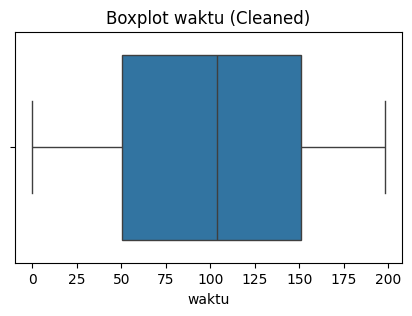

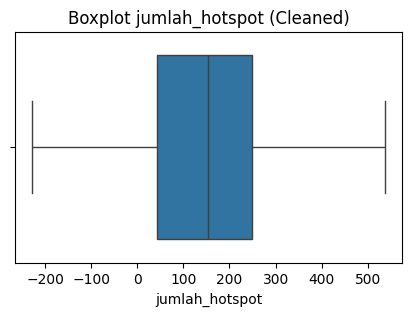

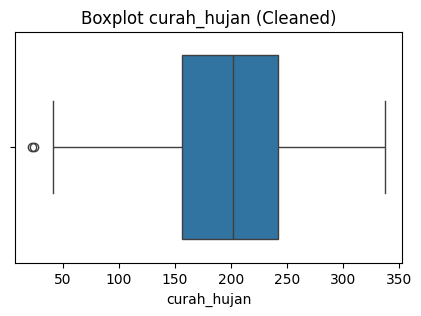

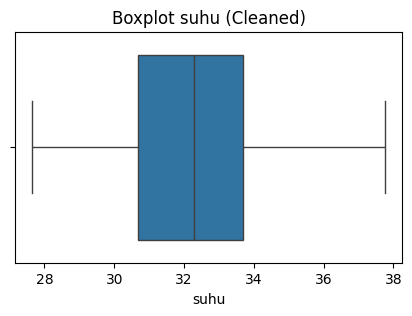

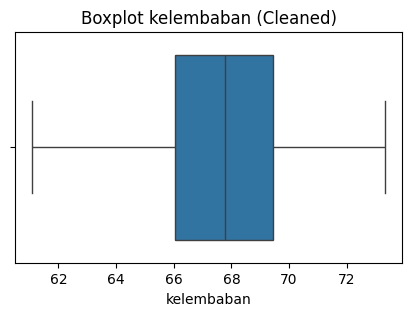

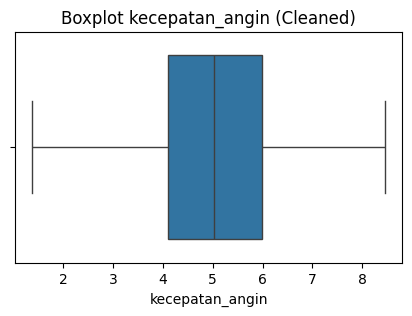

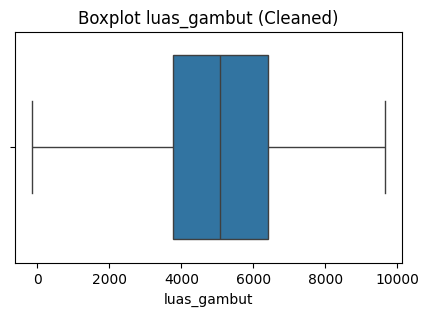

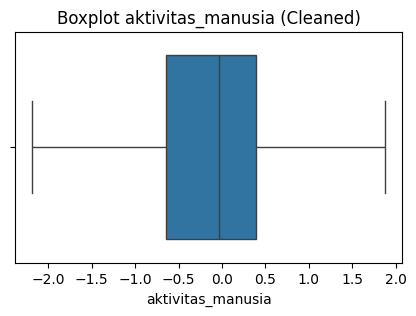

In [ ]:
for col in data_clean.columns:
  plt.figure(figsize=(5,3))
  sns.boxplot(x=data_clean[col])
  plt.title(f'Boxplot {col} (Cleaned)')
  plt.show()

## Scatter Plot

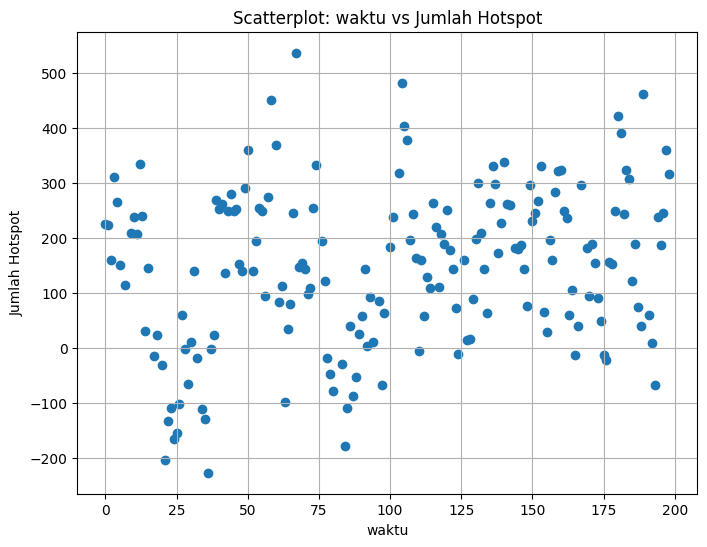

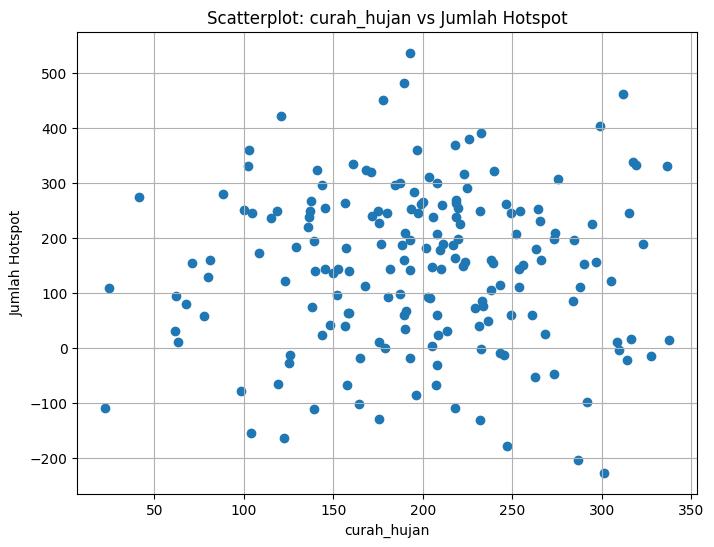

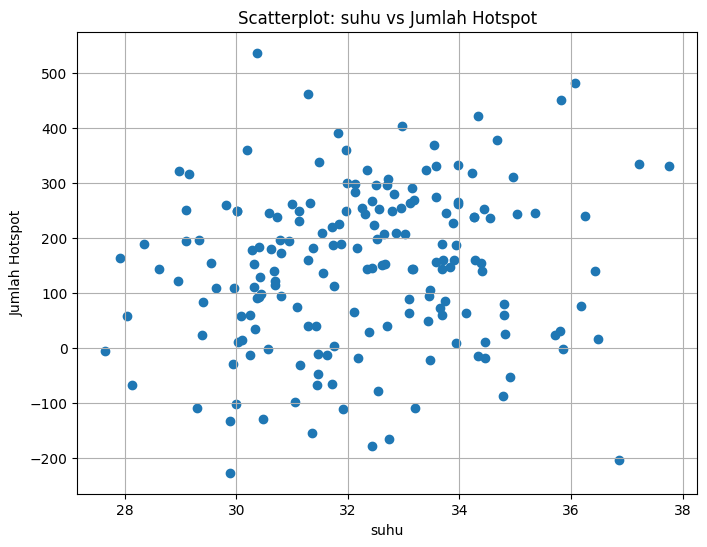

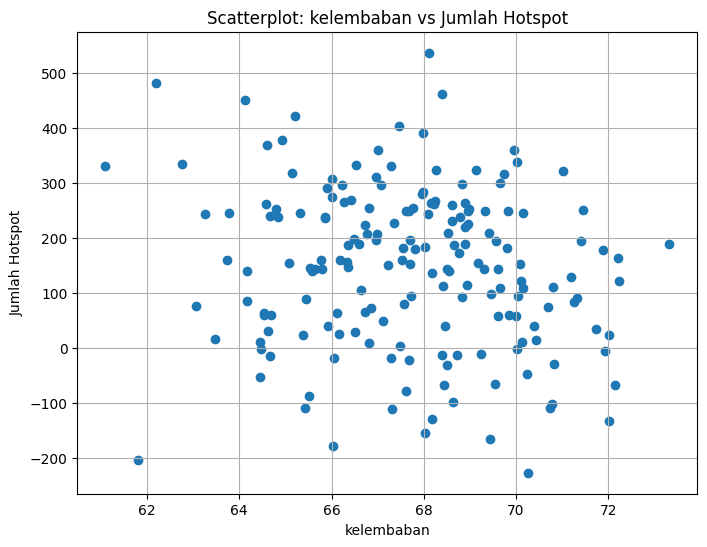

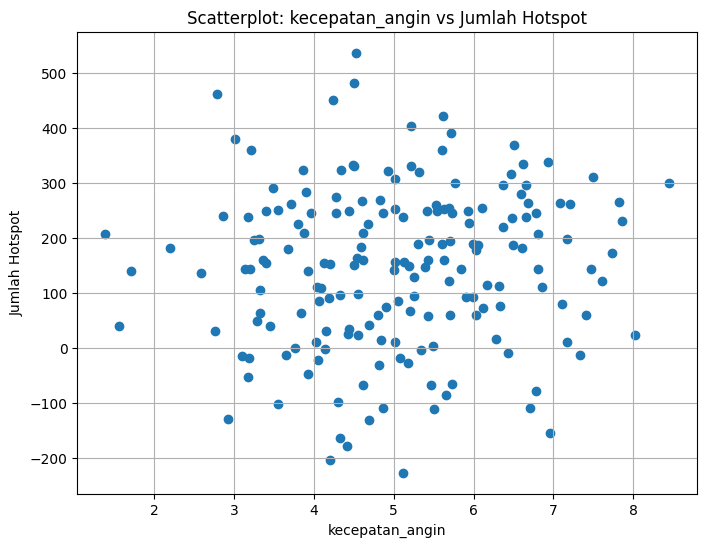

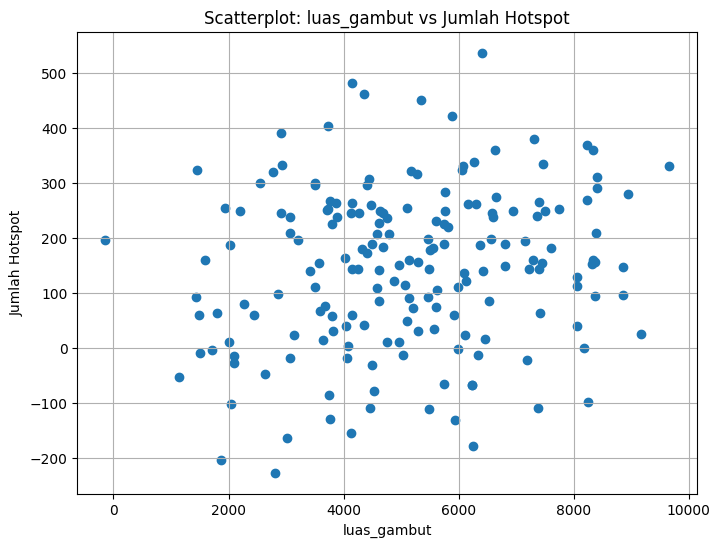

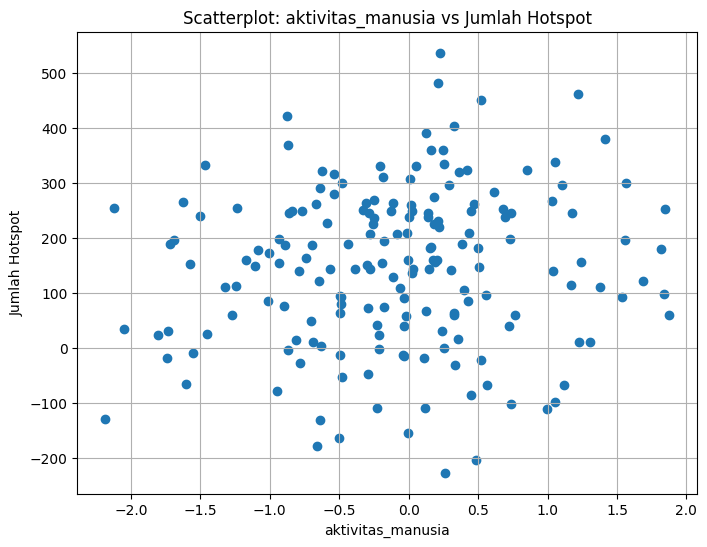

In [ ]:
y_plot_values_clean = data_clean['jumlah_hotspot']

for col_name in data_clean.columns:
    if col_name == 'jumlah_hotspot':
        continue
    plt.figure(figsize=(8, 6))
    plt.scatter(data_clean[col_name], y_plot_values_clean)
    plt.xlabel(col_name)
    plt.ylabel('Jumlah Hotspot')
    plt.title(f'Scatterplot: {col_name} vs Jumlah Hotspot')
    plt.grid(True)
    plt.show()

## Korelasi

In [ ]:
from scipy.stats import pearsonr

y_values_clean = data_clean['jumlah_hotspot']

for col_name in data_clean.columns:
    if col_name == 'jumlah_hotspot':
        continue
    korelasi_pearson, p_value = pearsonr(data_clean[col_name], y_values_clean)
    print(f"\nKoefisien Korelasi Pearson antara {col_name} dan Jumlah Hotspot: {korelasi_pearson:.3f} (p-value: {p_value:.3f})")


Koefisien Korelasi Pearson antara waktu dan Jumlah Hotspot: 0.223 (p-value: 0.002)

Koefisien Korelasi Pearson antara curah_hujan dan Jumlah Hotspot: 0.014 (p-value: 0.851)

Koefisien Korelasi Pearson antara suhu dan Jumlah Hotspot: 0.141 (p-value: 0.058)

Koefisien Korelasi Pearson antara kelembaban dan Jumlah Hotspot: -0.153 (p-value: 0.040)

Koefisien Korelasi Pearson antara kecepatan_angin dan Jumlah Hotspot: 0.081 (p-value: 0.279)

Koefisien Korelasi Pearson antara luas_gambut dan Jumlah Hotspot: 0.167 (p-value: 0.025)

Koefisien Korelasi Pearson antara aktivitas_manusia dan Jumlah Hotspot: 0.103 (p-value: 0.166)


# Model 1

In [ ]:
X = data_clean.drop(columns='jumlah_hotspot')
Y = data_clean[['jumlah_hotspot']]

In [ ]:
X.head()

,waktu,curah_hujan,suhu,kelembaban,kecepatan_angin,luas_gambut,aktivitas_manusia
0,0,294.647007,31.845645,68.966509,4.679783,5750.368465,-0.255473
1,1,220.978633,32.463660,66.728810,3.805794,3792.437093,0.185422
2,2,81.183365,33.903492,63.744425,3.364234,5135.557250,-1.169242
3,3,203.219077,34.952196,66.967840,7.502700,8401.212645,-0.183759
4,4,199.914905,33.977463,66.275833,7.819249,7391.018934,-1.626211


In [ ]:
Y.head()

,jumlah_hotspot
0,225.785850
1,224.105221
2,158.780413
3,310.220588
4,265.604392


## Split Data

In [ ]:
from sklearn.model_selection import train_test_split

X_admit_train, X_admit_test, Y_admit_train, Y_admit_test = train_test_split(X, Y, test_size=0.20, random_state=16)

## Model Training

In [ ]:
from sklearn.linear_model import LinearRegression

X_train = X_admit_train
X_test  = X_admit_test
Y_train = Y_admit_train.values.ravel()
Y_test  = Y_admit_test.values.ravel()

In [ ]:
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

## Uji Asumsi Klasik

### Uji Normalitas Residual

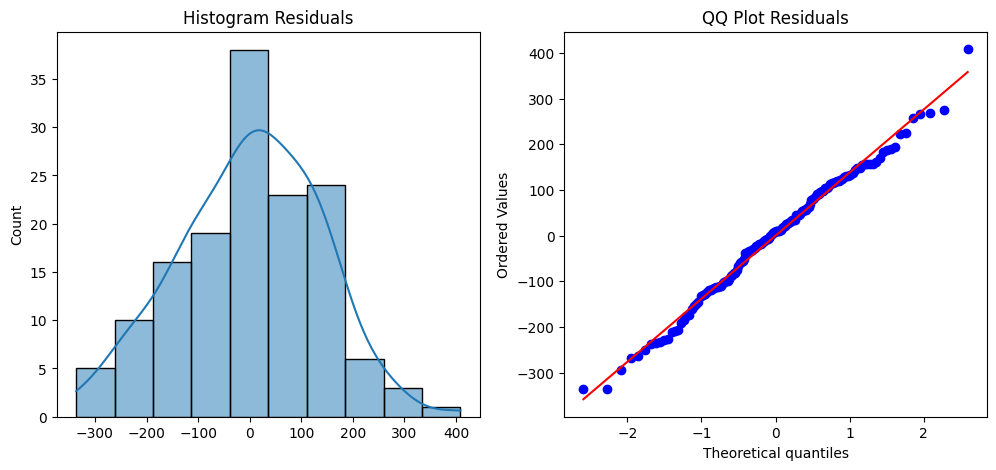

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt

Y_pred_train = model.predict(X_train)

residuals = Y_train - Y_pred_train

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(residuals, kde=True)
plt.title("Histogram Residuals")

plt.subplot(1,2,2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot Residuals")

plt.show()

Berdasarkan histogram dan plot, residual model menyebar mendekati distribusi normal, sehingga asumsi terpenuhi

### Uji Heterokedastisitas

In [ ]:
from statsmodels.stats.api import het_breuschpagan
from statsmodels.tools.tools import add_constant

X_train_const = add_constant(X_train)
bp_test = het_breuschpagan(residuals, X_train_const)

labels = [
    'LM Statistic',
    'LM-Test p-value',
    'F-Statistic',
    'F-Test p-value'
]

results = dict(zip(labels, bp_test))

for key, value in results.items():
    print(f"{key}: {value}")

LM Statistic: 8.927023656971771
LM-Test p-value: 0.2579380202892924
F-Statistic: 1.2839772492183579
F-Test p-value: 0.26268152121396815


Berdasarkan uji Breusch-Pagan, diperoleh p-value sebesar 0.258 (>0.05) sehingga dapat disimpulkan tidak mengalami heterokedastisitas, dan asumsi terpenuhi

### Uji Multikolinearitas

In [ ]:
X_train = X_train.copy()
X_test  = X_test.copy()

from statsmodels.tools.tools import add_constant
X_vif = add_constant(X_train)

from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

vif_df = pd.DataFrame()
vif_df["X"] = X_vif.columns
vif_df["vif_score"] = [vif(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_df = vif_df[vif_df.X != "const"]

print(vif_df)

                   X  vif_score
1              waktu   1.106796
2        curah_hujan   1.062234
3               suhu   5.136669
4         kelembaban   5.212585
5    kecepatan_angin   1.063549
6        luas_gambut   1.054288
7  aktivitas_manusia   1.125868


Multikol terdeteksi dimana terdapat 2 variabel dengan vif > 5, yaitu suhu dan kelembaban, maka drop 2 variabel tersebut


In [ ]:
X_train_new = X_train.drop(columns=['kelembaban','suhu'])
X_test_new  = X_test.drop(columns=['kelembaban','suhu'])

from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

X_vif = add_constant(X_train_new)

vif_df = pd.DataFrame()
vif_df["X"] = X_vif.columns
vif_df["vif_score"] = [
    vif(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_df = vif_df[vif_df.X != "const"]

print(vif_df)

                   X  vif_score
1              waktu   1.098144
2        curah_hujan   1.061925
3    kecepatan_angin   1.027871
4        luas_gambut   1.036345
5  aktivitas_manusia   1.103421


Sudah tidak ada variabel dengan vif > 5 sehingga asusmsi terpenuhi

### Uji Autokorelasi

In [ ]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residuals)
print(f"Durbin-Watson = {dw:.3f}")

Durbin-Watson = 1.995


Hasil Durbin-Watson 1.995 (mendekati 2), tidak ada autokorelasi sehingga asumsi terpenuhi

Buat model baru dengan X_train_new

In [ ]:
from sklearn.linear_model import LinearRegression

model_new = LinearRegression()
model_new.fit(X_train_new, Y_train)

LinearRegression()

In [ ]:
coef_df = pd.DataFrame({
    'feature':['intercept'] + X_train_new.columns.tolist(),
    'coefficient':[model_new.intercept_] + list(model_new.coef_)
})

coef_df

,feature,coefficient
0,intercept,21.661855
1,waktu,0.605719
2,curah_hujan,-0.017311
3,kecepatan_angin,-1.348540
4,luas_gambut,0.015252
5,aktivitas_manusia,11.148160


Model: Y = 21.661855 + 0.605719\*Waktu - 0.017311\*Curah Hujan - 1.348540\*Kecepatan Angin + 0.015252\*Luas Gambut + 11.148160\*Aktivitas Manusia

## Menggunakan OLS

In [ ]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train)
model_ols = sm.OLS(Y_train, X_train_const).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     3.331
Date:                Tue, 26 May 2026   Prob (F-statistic):            0.00263
Time:                        00:47:44   Log-Likelihood:                -918.96
No. Observations:                 145   AIC:                             1854.
Df Residuals:                     137   BIC:                             1878.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                61.0669   1145.79

## Evaluasi Model

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

Y_train_pred = model_new.predict(X_train_new)

r2_train = r2_score(Y_train, Y_train_pred)
mae_train = mean_absolute_error(Y_train, Y_train_pred)
rmse_train = np.sqrt(mean_squared_error(Y_train, Y_train_pred))

print("Train R2:", r2_train)
print("Train MAE:", mae_train)
print("Train RMSE:", rmse_train)

Train R2: 0.1023340876555987
Train MAE: 114.1680844776674
Train RMSE: 140.2300767985016


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

Y_test_pred = model_new.predict(X_test_new)

r2_test = r2_score(Y_test, Y_test_pred)
mae_test = mean_absolute_error(Y_test, Y_test_pred)
rmse_test = np.sqrt(mean_squared_error(Y_test, Y_test_pred))

print("Test R2:", r2_test)
print("Test MAE:", mae_test)
print("Test RMSE:", rmse_test)

Test R2: -0.019001543010833677
Test MAE: 107.52551674881502
Test RMSE: 130.72050736940324


Hasil evaluasi model menunjukkan bahwa model regresi memiliki kemampuan prediksi yang masih rendah dengan nilai R2 train sebesar 0.102 dan R2 test sebesar -0.019. Nilai tersebut menunjukkan variabel independent belum mampu menjelaskan variasi jumlah hotspot secara optimal. Selain itu, predik model masih memiliki error yang besar (MAE dan RMSE)

# Model 2

In [ ]:
X1 = data_clean[['curah_hujan','luas_gambut']]
Y1 = data_clean[['jumlah_hotspot']]

In [ ]:
X1.head()

,curah_hujan,luas_gambut
0,294.647007,5750.368465
1,220.978633,3792.437093
2,81.183365,5135.557250
3,203.219077,8401.212645
4,199.914905,7391.018934


In [ ]:
Y1.head()

,jumlah_hotspot
0,225.785850
1,224.105221
2,158.780413
3,310.220588
4,265.604392


## Split Data

In [ ]:
from sklearn.model_selection import train_test_split

X1_admit_train, X1_admit_test, Y1_admit_train, Y1_admit_test = train_test_split(X1, Y1, test_size=0.20, random_state=16)

## Model Training

In [ ]:
from sklearn.linear_model import LinearRegression

X1_train = X1_admit_train
X1_test  = X1_admit_test
Y1_train = Y1_admit_train.values.ravel()
Y1_test  = Y1_admit_test.values.ravel()

## Menggunakan OLS

In [ ]:
import statsmodels.api as sm

X1_train_const = sm.add_constant(X1_train)
model_ols = sm.OLS(Y1_train, X1_train_const).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     2.972
Date:                Tue, 26 May 2026   Prob (F-statistic):             0.0544
Time:                        00:59:14   Log-Likelihood:                -927.38
No. Observations:                 145   AIC:                             1861.
Df Residuals:                     142   BIC:                             1870.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          51.6794     51.330      1.007      

## Evaluasi Model

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

Y1_train_pred = model_ols.predict(X1_train_const)

r2_train = r2_score(Y1_train, Y1_train_pred)
mae_train = mean_absolute_error(Y1_train, Y1_train_pred)
rmse_train = np.sqrt(mean_squared_error(Y1_train, Y1_train_pred))

print("Train R2:", r2_train)
print("Train MAE:", mae_train)
print("Train RMSE:", rmse_train)

Train R2: 0.04017826503776878
Train MAE: 117.69104352881429
Train RMSE: 145.00370368081056


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm

X1_test_const = sm.add_constant(X1_test)
Y1_test_pred = model_ols.predict(X1_test_const)

r2_test = r2_score(Y1_test, Y1_test_pred)
mae_test = mean_absolute_error(Y1_test, Y1_test_pred)
rmse_test = np.sqrt(mean_squared_error(Y1_test, Y1_test_pred))

print("Test R2:", r2_test)
print("Test MAE:", mae_test)
print("Test RMSE:", rmse_test)

Test R2: -0.04731329358126013
Test MAE: 106.39299726846683
Test RMSE: 132.5240232665367


# Model 3

In [ ]:
X2 = data_clean[['suhu','kelembaban']]
Y2 = data_clean[['jumlah_hotspot']]

## Split Data

In [ ]:
from sklearn.model_selection import train_test_split

X2_admit_train, X2_admit_test, Y2_admit_train, Y2_admit_test = train_test_split(X2, Y2, test_size=0.20, random_state=16)

In [ ]:
X2.head()

,suhu,kelembaban
0,31.845645,68.966509
1,32.463660,66.728810
2,33.903492,63.744425
3,34.952196,66.967840
4,33.977463,66.275833


In [ ]:
Y2.head()

,jumlah_hotspot
0,225.785850
1,224.105221
2,158.780413
3,310.220588
4,265.604392


## Model Training

In [ ]:
from sklearn.linear_model import LinearRegression

X2_train = X2_admit_train
X2_test  = X2_admit_test
Y2_train = Y2_admit_train.values.ravel()
Y2_test  = Y2_admit_test.values.ravel()

## Menggunakan OLS

In [ ]:
import statsmodels.api as sm

X2_train_const = sm.add_constant(X2_train)
model_ols = sm.OLS(Y2_train, X2_train_const).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     3.234
Date:                Tue, 26 May 2026   Prob (F-statistic):             0.0423
Time:                        01:14:38   Log-Likelihood:                -927.12
No. Observations:                 145   AIC:                             1860.
Df Residuals:                     142   BIC:                             1869.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         51.5146   1165.482      0.044      0.9

## Evaluasi Model

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

Y2_train_pred = model_ols.predict(X2_train_const)

r2_train = r2_score(Y2_train, Y2_train_pred)
mae_train = mean_absolute_error(Y2_train, Y2_train_pred)
rmse_train = np.sqrt(mean_squared_error(Y2_train, Y2_train_pred))

print("Train R2:", r2_train)
print("Train MAE:", mae_train)
print("Train RMSE:", rmse_train)

Train R2: 0.04355949588113961
Train MAE: 116.78487946441302
Train RMSE: 144.74807102778473


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm

X2_test_const = sm.add_constant(X2_test)
Y2_test_pred = model_ols.predict(X2_test_const)

r2_test = r2_score(Y2_test, Y2_test_pred)
mae_test = mean_absolute_error(Y2_test, Y2_test_pred)
rmse_test = np.sqrt(mean_squared_error(Y2_test, Y2_test_pred))

print("Test R2:", r2_test)
print("Test MAE:", mae_test)
print("Test RMSE:", rmse_test)

Test R2: -0.11841893803123948
Test MAE: 111.70234196262632
Test RMSE: 136.94890375393825
